# **BÀI THỰC HÀNH SỐ 2: MARKOV DECISION PROCESS, HÀM GIÁ TRỊ VÀ QUY HOẠCH ĐỘNG**

**HỌC PHẦN:** HỌC TĂNG CƯỜNG CƠ BẢN - REINFORCEMENT LEARNING

**Sinh viên thực hiện:** *Lê Thị Thúy*

**Mã sinh viên:** *22010846*

**Mục tiêu:**
* Biểu diễn Markov chain bằng ma trận xác suất chuyển trạng thái.
* Kiểm tra tính hợp lệ của transition matrix.
* Mô phỏng Markov chain.
* Biểu diễn một MDP rời rạc.
* Phân biệt state, action, transition probability và reward.
* So sánh Value Iteration và Policy Iteration.
* Biểu diễn deterministic policy và stochastic policy.
* Tổ chức một chương trình Dynamic Programming hoàn chỉnh.

## **CHUẨN BỊ MÔI TRƯỜNG**
### **2.1. Cài đặt thư viện và môi trường**

In [2]:
%pip install gymnasium[toy-text]

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\LENOVO\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
!pip install gymnasium[toy-text]
!pip install numpy matplotlib jupyter

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\LENOVO\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\LENOVO\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
!python --version
!pip show gymnasium
!pip show numpy

Python 3.13.14
Name: gymnasium
Version: 1.3.0
Summary: A standard API for reinforcement learning and a diverse set of reference environments (formerly Gym).
Home-page: https://farama.org
Author: 
Author-email: Farama Foundation <contact@farama.org>
License: MIT License
Location: C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages
Requires: cloudpickle, farama-notifications, numpy, typing-extensions
Required-by: 
Name: numpy
Version: 2.4.2
Summary: Fundamental package for array computing in Python
Home-page: https://numpy.org
Author: Travis E. Oliphant et al.
Author-email: 
License-Expression: BSD-3-Clause AND 0BSD AND MIT AND Zlib AND CC0-1.0
Location: C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages
Requires: 
Required-by: contourpy, gymnasium, h5py, keras, matplotlib, ml_dtypes, opencv-python, pandas, scikit

### **2.2. Làm quen model của FrozenLake**

In [5]:
import gymnasium as gym

env = gym.make(
    "FrozenLake-v1",
    map_name="4x4",
    is_slippery=True
)

In [6]:
n_states = env.observation_space.n
n_actions = env.action_space.n
P = env.unwrapped.P

state = 0
action = 0
for probability, next_state, reward, terminated in P[state][action]:
    print(probability, next_state, reward, terminated)

0.33333333333333337 0 0 False
0.3333333333333333 0 0 False
0.33333333333333337 4 0 False


### **2.3. Quy ước action FrozenLake**

In [7]:
# Khai báo quy ước tên hành động (Action Names)
ACTION_NAMES = {
    0: "LEFT",
    1: "DOWN",
    2: "RIGHT",
    3: "UP",
}

# Khai báo quy ước ký hiệu hành động (Action Symbols)
ACTION_SYMBOLS = {
    0: "←",
    1: "↓",
    2: "→",
    3: "↑",
}

In [8]:
action = 1
print(f"Hành động {action}: {ACTION_NAMES[action]} ({ACTION_SYMBOLS[action]})")

Hành động 1: DOWN (↓)


### **2.4. Tạo cấu trúc thư mục (Dùng trong colab hoặc Visual Studio Code)**

In [9]:
import os


def find_lab_root(folder_name="Lab02"):
    """
    Tìm thư mục gốc Lab02
    """
    cwd = os.path.abspath(os.getcwd())

    if os.path.basename(cwd) == folder_name:
        return cwd

    parent = cwd
    while True:
        if os.path.basename(parent) == folder_name:
            return parent
        new_parent = os.path.dirname(parent)
        if new_parent == parent:  # đã lên tới ổ đĩa gốc mà không thấy
            break
        parent = new_parent

    return os.path.join(cwd, folder_name)


BASE = find_lab_root("Lab02")

folders = [
    BASE,
    f"{BASE}/src",
    f"{BASE}/notebooks",
    f"{BASE}/figures",
    f"{BASE}/data",
]
for f in folders:
    os.makedirs(f, exist_ok=True)

files = [
    f"{BASE}/README.md",
    f"{BASE}/requirements.txt",
    f"{BASE}/src/mdp_utils.py",
    f"{BASE}/src/main.py",
    f"{BASE}/data/README.md",
] + [f"{BASE}/src/bai{str(i).zfill(2)}.py" for i in range(1, 37)]

for f in files:
    if not os.path.exists(f):
        open(f, "a").close()

print("Thư mục làm việc hiện tại (cwd):", os.getcwd())
print("Đã xác định BASE (Lab02) tại:", BASE)
print("Đã tạo cấu trúc thư mục Lab02")

Thư mục làm việc hiện tại (cwd): c:\Users\LENOVO\Downloads\Học Tăng Cường Cơ Bản\Thực Hành\Lab02
Đã xác định BASE (Lab02) tại: c:\Users\LENOVO\Downloads\Học Tăng Cường Cơ Bản\Thực Hành\Lab02
Đã tạo cấu trúc thư mục Lab02


## **Bài Tập Phần A: Markov Chain**

### **Bài 1: Tạo transition matrix**
Xây dựng ma trận chuyển trạng thái 3×3 cho Markov chain thời tiết (Sunny, Cloudy, Rainy), mỗi hàng tổng = 1.

**Mục đích:** Làm quen cách biểu diễn Markov chain bằng ma trận xác suất.

In [10]:
import os

file_path = os.path.join(BASE, "src", "bai01.py")

code_content = '''"""Bài 01: Tạo transition matrix cho Markov chain thời tiết (Sunny, Cloudy, Rainy)."""

import numpy as np

STATES = ["Sunny", "Cloudy", "Rainy"]

P = np.array([
    [0.7, 0.2, 0.1],   # từ Sunny
    [0.3, 0.4, 0.3],   # từ Cloudy
    [0.2, 0.3, 0.5],   # từ Rainy
])


def main():
    print("Transition matrix P (hàng = state hiện tại, cột = state kế tiếp):")
    print(P)
    print("Tổng mỗi hàng:", P.sum(axis=1))


if __name__ == "__main__":
    main()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

Transition matrix P (hàng = state hiện tại, cột = state kế tiếp):
[[0.7 0.2 0.1]
 [0.3 0.4 0.3]
 [0.2 0.3 0.5]]
Tổng mỗi hàng: [1. 1. 1.]


### **Bài 2. Kiểm tra transition matrix**

Viết hàm kiểm tra ma trận vuông, phần tử ∈ [0,1], tổng mỗi hàng ≈ 1.

**Mục đích:** Đảm bảo mọi transition matrix sử dụng sau này đều hợp lệ.

In [11]:
import os

file_path = os.path.join(BASE, "src", "bai02.py")
code_content = '''"""Bài 02: Kiểm tra tính hợp lệ của một transition matrix."""

import numpy as np
from bai01 import P


def validate_transition_matrix(P, tol=1e-10):
    P = np.asarray(P)
    if P.ndim != 2 or P.shape[0] != P.shape[1]:
        return False
    if np.any(P < 0) or np.any(P > 1):
        return False
    row_sums = P.sum(axis=1)
    return bool(np.all(np.abs(row_sums - 1.0) < tol))


if __name__ == "__main__":
    print("P hợp lệ:", validate_transition_matrix(P))
    bad_P = np.array([[0.5, 0.4], [0.3, 0.3]])
    print("bad_P hợp lệ:", validate_transition_matrix(bad_P))
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)


!python "{file_path}"

P hợp lệ: True
bad_P hợp lệ: False


**Nhận xét:** P đạt cả 3 điều kiện (vuông, giá trị trong [0,1], tổng hàng = 1) nên hợp lệ; bad_P có tổng hàng ≠ 1 nên bị phát hiện sai ngay lập tức.

### **Bài 3: Tính xác suất trạng thái kế tiếp**
Từ phân phối ban đầu p0, tính phân phối sau 1 bước bằng p0 @ P (không hard-code).

**Mục đích:** Hiểu phép nhân vector-ma trận biểu diễn một bước Markov chain.

In [12]:
import os

file_path = os.path.join(BASE, "src", "bai03.py")
code_content = '''"""Bài 03: Tính xác suất trạng thái kế tiếp"""

import numpy as np
from bai01 import P

p0 = np.array([1.0, 0.0, 0.0])

if __name__ == "__main__":
    p1 = p0 @ P
    print("p0 =", p0)
    print("p1 =", p1)
    print("Tổng p1 =", p1.sum())
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)


!python "{file_path}"

p0 = [1. 0. 0.]
p1 = [0.7 0.2 0.1]
Tổng p1 = 0.9999999999999999


### **Bài 4: Distribution sau nhiều bước**
Viết state_distribution(p0, P, n_steps) tính phân phối tại t = 1, 2, 5, 10, 50.

**Mục đích:** Quan sát chain tiến dần tới stationary distribution.

In [13]:
import os

file_path = os.path.join(BASE, "src", "bai04.py")
code_content = '''"""Bài 04: Phân phối trạng thái sau n bước"""

import numpy as np
from bai01 import P
from bai03 import p0


def state_distribution(p0, P, n_steps):
    p = np.array(p0, dtype=float)
    for _ in range(n_steps):
        p = p @ P
    return p


if __name__ == "__main__":
    for t in [1, 2, 5, 10, 50]:
        print(f"t={t:2d}: {state_distribution(p0, P, t)}")
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

t= 1: [0.7 0.2 0.1]
t= 2: [0.57 0.25 0.18]
t= 5: [0.46848 0.2794  0.25212]
t=10: [0.45680544 0.28253268 0.26066188]
t=50: [0.45652174 0.2826087  0.26086957]


**Nhận xét:** Từ t=10 đến t=50 phân phối gần như không đổi → chain đã hội tụ về stationary distribution.

### **Bài 5: Mô phỏng Markov Chain**
Viết sample_next_state dùng rng.choice, mô phỏng chuỗi 30 bước.
**Mục đích:** Chuyển từ mô hình xác suất sang mô phỏng thực tế bằng sampling.


In [14]:
import os

file_path = os.path.join(BASE, "src", "bai05.py")
code_content = '''"""Bài 05: Mô phỏng Markov chain"""

import numpy as np
from bai01 import P, STATES


def sample_next_state(current_state, P, rng):
    return rng.choice(len(P), p=P[current_state])


if __name__ == "__main__":
    rng = np.random.default_rng(42)
    state = 0
    trajectory = [state]
    for _ in range(30):
        state = sample_next_state(state, P, rng)
        trajectory.append(state)
    print("Chuỗi state (tên):", [STATES[s] for s in trajectory])
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)


!python "{file_path}"

Chuỗi state (tên): ['Sunny', 'Cloudy', 'Cloudy', 'Rainy', 'Rainy', 'Sunny', 'Rainy', 'Rainy', 'Rainy', 'Sunny', 'Sunny', 'Sunny', 'Rainy', 'Rainy', 'Rainy', 'Cloudy', 'Sunny', 'Sunny', 'Sunny', 'Cloudy', 'Cloudy', 'Rainy', 'Cloudy', 'Rainy', 'Rainy', 'Rainy', 'Sunny', 'Sunny', 'Sunny', 'Sunny', 'Sunny']


**Nhận xét:** Chuỗi mô phỏng vẫn ưu tiên ở lại Sunny/Rainy lâu hơn Cloudy, phù hợp với xác suất tự - lặp cao (0.7, 0.5) của hai trạng thái này trong P.

### **Bài 6: So sánh lý thuyết và mô phỏng**
Mô phỏng ≥100,000 transition, so sánh tần suất với distribution lý thuyết, vẽ biểu đồ.

**Mục đích:** Kiểm chứng thực nghiệm sự hội tụ của Markov chain (luật số lớn).

Lý thuyết : [0.45652174 0.2826087  0.26086957]
Mô phỏng  : [0.45606 0.28175 0.26219]
Sai lệch  : [0.00046174 0.0008587  0.00132043]
Figure(600x400)


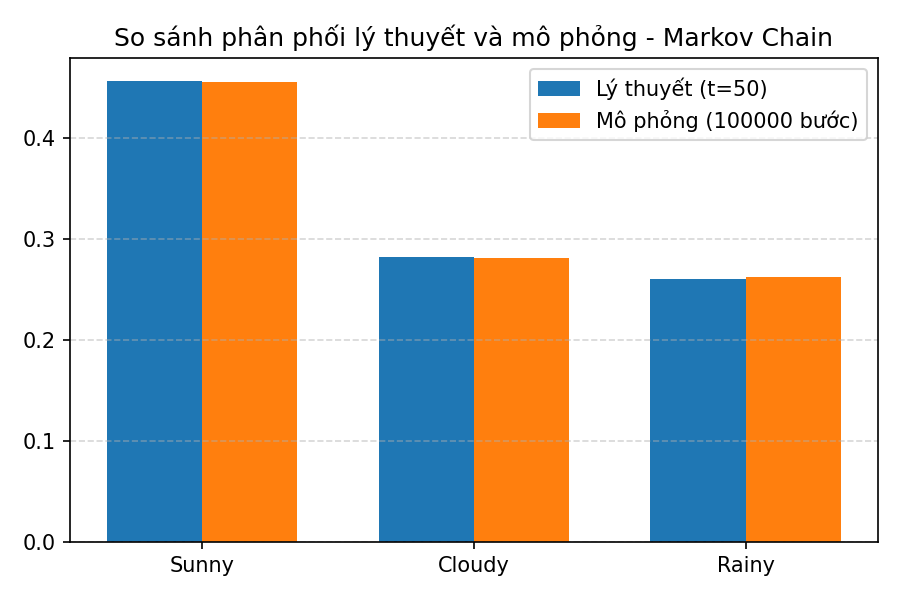

In [15]:
import os

fig_path = os.path.join(BASE, "figures", "markov_distribution.png")
file_path = os.path.join(BASE, "src", "bai06.py")

code_content = f'''"""Bài 06: So sánh phân phối lý thuyết và mô phỏng"""

FIG_PATH = {fig_path!r}

import numpy as np
import matplotlib.pyplot as plt
from bai01 import P, STATES
from bai04 import state_distribution
from bai05 import sample_next_state

N_TRANSITIONS = 100_000


def simulate_frequency(P, n_steps, start_state=0, seed=123):
    rng = np.random.default_rng(seed)
    state = start_state
    counts = np.zeros(len(P))
    for _ in range(n_steps):
        state = sample_next_state(state, P, rng)
        counts[state] += 1
    return counts / counts.sum()


if __name__ == "__main__":
    theoretical = state_distribution(np.array([1.0, 0.0, 0.0]), P, n_steps=50)
    empirical = simulate_frequency(P, N_TRANSITIONS)

    print("Lý thuyết :", theoretical)
    print("Mô phỏng  :", empirical)
    print("Sai lệch  :", np.abs(theoretical - empirical))

    x = np.arange(len(STATES))
    width = 0.35
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(x - width / 2, theoretical, width, label="Lý thuyết (t=50)")
    ax.bar(x + width / 2, empirical, width, label="Mô phỏng (100000 bước)")
    ax.set_xticks(x)
    ax.set_xticklabels(STATES)
    ax.set_title("So sánh phân phối lý thuyết và mô phỏng - Markov Chain")
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    fig.tight_layout()
    fig.savefig(FIG_PATH, dpi=150)
    
    plt.show()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

from IPython.display import Image, display

fig_path = os.path.join(BASE, "figures", "markov_distribution.png")
display(Image(filename=fig_path))

**Nhận xét:**
* Tần suất mô phỏng với 100,000 transition rất gần phân phối lý thuyết, sai lệch < 0.002.
* Chain ergodic sẽ hội tụ về stationary distribution bất kể state ban đầu. 
* Số bước mô phỏng càng lớn thì sai lệch càng nhỏ (luật số lớn). 
* Sai số còn lại chỉ do tính ngẫu nhiên hữu hạn của sampling.

## **Bài Tập Phần B: Reward, Return Và Discount Factor**

### **Bài 7: Undiscounted return**
Viết compute_return(rewards, gamma), tính với gamma = 1.0.

**Mục đích:** Hiểu công thức return tổng quát trước khi thêm discount.

In [16]:
import os

file_path = os.path.join(BASE, "src", "bai07.py")
code_content = '''"""Bài 07: Undiscounted return"""


def compute_return(rewards, gamma):
    G = 0.0
    for k, r in enumerate(rewards):
        G += (gamma ** k) * r
    return G


if __name__ == "__main__":
    rewards = [1, 1, 1, 1, 1]
    print("rewards =", rewards)
    print("Undiscounted return G (gamma=1.0) =", compute_return(rewards, gamma=1.0))
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

rewards = [1, 1, 1, 1, 1]
Undiscounted return G (gamma=1.0) = 5.0


**Nhận xét:** Khi gamma = 1, return khi này là tổng cộng dồn toàn bộ reward.

### **Bài 8: Discounted return**
Tính return với gamma = 0.0, 0.5, 0.9, 0.99, 1.0 và lập bảng.

In [17]:
import os

file_path = os.path.join(BASE, "src", "bai08.py")
code_content = '''"""Bài 08: Discounted return"""

from bai07 import compute_return

rewards = [1, 1, 1, 1, 1]
gammas = [0.0, 0.5, 0.9, 0.99, 1.0]

if __name__ == "__main__":
    print(f"{'Gamma':>6} | {'Return':>10}")
    print("-" * 20)
    for g in gammas:
        print(f"{g:6.2f} | {compute_return(rewards, g):10.4f}")
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

 Gamma |     Return
--------------------
  0.00 |     1.0000
  0.50 |     1.9375
  0.90 |     4.0951
  0.99 |     4.9010
  1.00 |     5.0000


**Nhận xét:** Gamma càng lớn thì return càng gần với tổng reward thực (5.0); gamma = 0 chỉ tính đúng reward bước đầu tiên.

### **Bài 9: Return từ cuối Episode**
Viết discounted_returns(rewards, gamma) tính G_t bằng đệ quy ngược.

**Mục đích:** Cài đặt cách tính return

In [18]:
import os

file_path = os.path.join(BASE, "src", "bai09.py")
code_content = '''"""Bài 09: Tính return G_t cho từng bước"""

import numpy as np


def discounted_returns(rewards, gamma):
    G = np.zeros(len(rewards))
    running = 0.0
    for t in reversed(range(len(rewards))):
        running = rewards[t] + gamma * running
        G[t] = running
    return G


if __name__ == "__main__":
    rewards = [0, 0, 0, 1]
    G = discounted_returns(rewards, gamma=0.9)
    for t, g in enumerate(G):
        print(f"G_{t} = {g:.4f}")
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

G_0 = 0.7290
G_1 = 0.8100
G_2 = 0.9000
G_3 = 1.0000


### **Bài 10: Ảnh hưởng của Gamma**
Vẽ G_0 theo 101 giá trị gamma ∈ [0,1] với rewards=[0,0,0,0,10].

**Mục đích:** Trực quan hóa mối quan hệ giữa gamma và giá trị của reward trễ.

G_0 tại gamma = 0: 0.0 | tại gamma = 1: 10.0


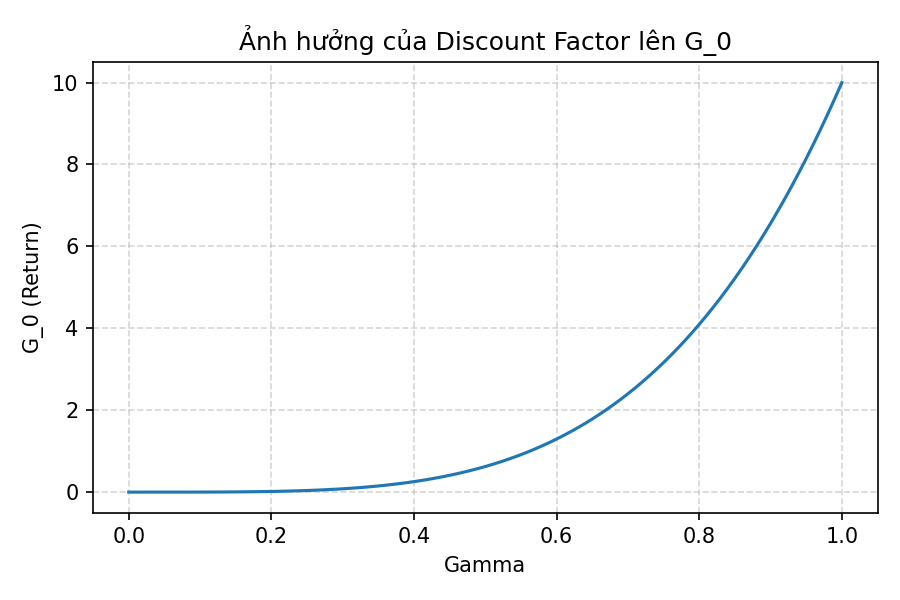

In [19]:
import os

fig_path = os.path.join(BASE, "figures", "gamma_comparison.png")
file_path = os.path.join(BASE, "src", "bai10.py")

code_content = f'''"""Bài 10: Ảnh hưởng của gamma lên G_0"""

FIG_PATH = {fig_path!r}

import numpy as np
import matplotlib.pyplot as plt
from bai07 import compute_return

rewards = [0, 0, 0, 0, 10]
gammas = np.linspace(0, 1, 101)

if __name__ == "__main__":
    returns = [compute_return(rewards, g) for g in gammas]

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(gammas, returns, color="tab:blue")
    ax.set_title("Ảnh hưởng của Discount Factor lên G_0")
    ax.set_xlabel("Gamma"); ax.set_ylabel("G_0 (Return)")
    ax.grid(True, linestyle="--", alpha=0.5)
    fig.tight_layout()
    fig.savefig(FIG_PATH, dpi=150)
    print("G_0 tại gamma = 0:", returns[0], "| tại gamma = 1:", returns[-1])
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)


!python "{file_path}"

from IPython.display import Image, display

fig_path = os.path.join(BASE, "figures", "gamma_comparison.png")
display(Image(filename=fig_path))

**Nhận xét:** Đường cong tăng dần đơn điệu (không tuyến tính) — reward ở xa (bước thứ 5) chỉ có giá trị đầy đủ (10) khi gamma = 1, và gần như 0 khi gamma = 0.

### **Bài 11: Reward sớm và reward trễ**
So sánh sequence_A=[5,0,0,0,0] và sequence_B=[0,0,0,0,10], tìm khoảng gamma mà B > A.

**Mục đích:** Minh họa cách gamma điều khiển việc agent thích reward gần hay xa.

In [20]:
import os

file_path = os.path.join(BASE, "src", "bai11.py")
code_content = '''"""Bài 11: So sánh reward sớm và reward trễ"""

import numpy as np
from bai07 import compute_return

sequence_A = [5, 0, 0, 0, 0]
sequence_B = [0, 0, 0, 0, 10]

if __name__ == "__main__":
    gammas = np.linspace(0, 1, 1001)
    returns_A = np.array([compute_return(sequence_A, g) for g in gammas])
    returns_B = np.array([compute_return(sequence_B, g) for g in gammas])

    B_greater = gammas[returns_B > returns_A]
    if len(B_greater) > 0:
        print(f"B > A khi gamma trong khoảng [{B_greater.min():.3f}, {B_greater.max():.3f}]")

    diff = returns_B - returns_A
    sign_change = np.where(np.diff(np.sign(diff)) != 0)[0]
    for idx in sign_change:
        print(f"Điểm giao xấp xỉ gamma = {gammas[idx]:.4f}")
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)


!python "{file_path}"

B > A khi gamma trong khoảng [0.841, 1.000]
Điểm giao xấp xỉ gamma = 0.8400


**Nhận xét:** Chỉ khi agent đủ kiên nhẫn (gamma > 0.84) thì phần thưởng lớn nhưng ở xa (B) mới có lợi hơn phần thưởng nhỏ nhưng đến sớm (A).

## **Bài Tập Phần C: Mô Hình Hóa Một MDP Nhỏ**

### **Bài 12: Xây dựng MDP hai state**
Tạo MDP tự thiết kế: 2 state, 2 action, dạng P[s][a] = [(prob, next_state, reward, terminated)].

**Mục đích:** Làm quen cấu trúc dữ liệu transition model dùng xuyên suốt bài thực hành

In [21]:
import os

file_path = os.path.join(BASE, "src", "bai12.py")
code_content = '''"""Bài 12: Xây dựng MDP hai state, hai action."""

P = {
    0: {
        0: [(0.8, 0, 0.0, False), (0.2, 1, 1.0, False)],
        1: [(0.3, 0, 0.0, False), (0.7, 1, 2.0, False)],
    },
    1: {
        0: [(0.6, 0, 1.0, False), (0.4, 1, 0.0, True)],
        1: [(1.0, 1, 5.0, True)],
    },
}
N_STATES, N_ACTIONS = 2, 2

if __name__ == "__main__":
    for s in P:
        for a in P[s]:
            print(f"State {s}, Action {a}: {P[s][a]}")
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

State 0, Action 0: [(0.8, 0, 0.0, False), (0.2, 1, 1.0, False)]
State 0, Action 1: [(0.3, 0, 0.0, False), (0.7, 1, 2.0, False)]
State 1, Action 0: [(0.6, 0, 1.0, False), (0.4, 1, 0.0, True)]
State 1, Action 1: [(1.0, 1, 5.0, True)]


### **Bài 13: Kiểm tra Model MDP**
Viết validate_mdp(P, n_states, n_actions) kiểm tra tổng xác suất mỗi (state, action) = 1.

**Mục đích:** Đảm bảo model tự thiết kế không sai sót trước khi dùng cho Bellman backup.

In [22]:
import os

file_path = os.path.join(BASE, "src", "bai13.py")
code_content = '''"""Bài 13: Kiểm tra MDP model."""

import numpy as np
from bai12 import P, N_STATES, N_ACTIONS


def validate_mdp(P, n_states, n_actions):
    ok = True
    for s in range(n_states):
        for a in range(n_actions):
            total_prob = sum(t[0] for t in P[s][a])
            if not np.isclose(total_prob, 1.0):
                print(f"Invalid transition at state={s}, action={a}")
                ok = False
    return ok


if __name__ == "__main__":
    print("MDP hợp lệ:", validate_mdp(P, N_STATES, N_ACTIONS))
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

MDP hợp lệ: True


### **Bài 14: Deterministic policy**
Tạo mảng policy (mỗi state → 1 action cố định) và hàm in policy.

**Mục đích:** Làm quen cách biểu diễn deterministic policy bằng mảng numpy.

In [23]:
import os

file_path = os.path.join(BASE, "src", "bai14.py")
code_content = '''"""Bài 14: Deterministic policy"""

import numpy as np

policy = np.array([1, 0])  # State 0 -> Action 1, State 1 -> Action 0


def print_policy(policy):
    for s, a in enumerate(policy):
        print(f"State {s} -> Action {a}")


if __name__ == "__main__":
    print_policy(policy)
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)


!python "{file_path}"

State 0 -> Action 1
State 1 -> Action 0


### **Bài 15: Stochastic policy**
Tạo uniform random policy, kiểm tra tổng xác suất mỗi hàng = 1.

**Mục đích:** Phân biệt deterministic vs stochastic policy — nền tảng cho Policy Evaluation.

In [24]:
import os

file_path = os.path.join(BASE, "src", "bai15.py")
code_content = '''"""Bài 15: Stochastic policy (uniform random)."""

import numpy as np
from bai12 import N_STATES, N_ACTIONS

policy = np.ones((N_STATES, N_ACTIONS)) / N_ACTIONS

if __name__ == "__main__":
    print("Stochastic policy:\\n", policy)
    print("Tổng mỗi hàng:", policy.sum(axis=1))
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

Stochastic policy:
 [[0.5 0.5]
 [0.5 0.5]]
Tổng mỗi hàng: [1. 1.]


## **Bài Tập Phần D: Khám Phá Model FrozenLake**

### **Bài 16: Thông tin cơ bản**
Tạo FrozenLake-v1 (4x4, slippery), in số state, số action, observation ban đầu.

**Mục đích:** Làm quen môi trường chuẩn dùng cho toàn bộ phần Dynamic Programming.

In [25]:
import os

file_path = os.path.join(BASE, "src", "bai16.py")
code_content = '''"""Bài 16: Thông tin cơ bản của FrozenLake-v1."""

import gymnasium as gym


def create_environment(map_name="4x4", is_slippery=True):
    return gym.make("FrozenLake-v1", map_name=map_name, is_slippery=is_slippery)


if __name__ == "__main__":
    env = create_environment()
    obs, info = env.reset(seed=42)
    print("Number of states:", env.observation_space.n)
    print("Number of actions:", env.action_space.n)
    print("Initial observation:", obs)
    env.close()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

Number of states: 16
Number of actions: 4
Initial observation: 0


### **Bài 17: In Transition Model của một state**
Duyệt env.unwrapped.P[0][action] cho từng action.

**Mục đích:** Hiểu cấu trúc dữ liệu transition model thật của Gymnasium.

In [26]:
import os

file_path = os.path.join(BASE, "src", "bai17.py")
code_content = '''"""Bài 17: In transition model của state=0."""

from bai16 import create_environment

ACTION_NAMES = {0: "LEFT", 1: "DOWN", 2: "RIGHT", 3: "UP"}

if __name__ == "__main__":
    env = create_environment()
    P = env.unwrapped.P
    for action in range(env.action_space.n):
        print(f"\\nAction {action} ({ACTION_NAMES[action]}):")
        for probability, next_state, reward, terminated in P[0][action]:
            print(f"  p={probability:.3f}, next_state={next_state}, reward={reward}, terminated={terminated}")
    env.close()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"


Action 0 (LEFT):
  p=0.333, next_state=0, reward=0, terminated=False
  p=0.333, next_state=0, reward=0, terminated=False
  p=0.333, next_state=4, reward=0, terminated=False

Action 1 (DOWN):
  p=0.333, next_state=0, reward=0, terminated=False
  p=0.333, next_state=4, reward=0, terminated=False
  p=0.333, next_state=1, reward=0, terminated=False

Action 2 (RIGHT):
  p=0.333, next_state=4, reward=0, terminated=False
  p=0.333, next_state=1, reward=0, terminated=False
  p=0.333, next_state=0, reward=0, terminated=False

Action 3 (UP):
  p=0.333, next_state=1, reward=0, terminated=False
  p=0.333, next_state=0, reward=0, terminated=False
  p=0.333, next_state=0, reward=0, terminated=False


### **Bài 18: Hàm Describe_state()**
Viết hàm mô tả toàn bộ action/transition tại một state, kiểm thử với state 0, 1, 14.

**Mục đích:** Tạo công cụ tiện lợi để kiểm tra model tại bất kỳ state nào.

In [27]:
import os

file_path = os.path.join(BASE, "src", "bai18.py")
code_content = '''"""Bài 18: Hàm describe_state()"""

from bai16 import create_environment
from bai17 import ACTION_NAMES


def describe_state(env, state):
    P = env.unwrapped.P
    print(f"=== State {state} ===")
    for action in range(env.action_space.n):
        print(f"  Action {action} ({ACTION_NAMES[action]}):")
        for probability, next_state, reward, terminated in P[state][action]:
            print(f"    p={probability:.3f}, next_state={next_state}, reward={reward}, terminated={terminated}")


if __name__ == "__main__":
    env = create_environment()
    for s in [0, 1, 14]:
        describe_state(env, s)
    env.close()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

=== State 0 ===
  Action 0 (LEFT):
    p=0.333, next_state=0, reward=0, terminated=False
    p=0.333, next_state=0, reward=0, terminated=False
    p=0.333, next_state=4, reward=0, terminated=False
  Action 1 (DOWN):
    p=0.333, next_state=0, reward=0, terminated=False
    p=0.333, next_state=4, reward=0, terminated=False
    p=0.333, next_state=1, reward=0, terminated=False
  Action 2 (RIGHT):
    p=0.333, next_state=4, reward=0, terminated=False
    p=0.333, next_state=1, reward=0, terminated=False
    p=0.333, next_state=0, reward=0, terminated=False
  Action 3 (UP):
    p=0.333, next_state=1, reward=0, terminated=False
    p=0.333, next_state=0, reward=0, terminated=False
    p=0.333, next_state=0, reward=0, terminated=False
=== State 1 ===
  Action 0 (LEFT):
    p=0.333, next_state=1, reward=0, terminated=False
    p=0.333, next_state=0, reward=0, terminated=False
    p=0.333, next_state=5, reward=0, terminated=True
  Action 1 (DOWN):
    p=0.333, next_state=0, reward=0, terminate

### **Bài 19: Kiểm tra tổng xác suất transition**
Duyệt mọi (state, action), xác nhận tổng xác suất = 1.

**Mục đích:** Đảm bảo model FrozenLake hợp lệ trước khi dùng Bellman backup.

In [28]:
import os

file_path = os.path.join(BASE, "src", "bai19.py")
code_content = '''"""Bài 19: Kiểm tra tổng xác suất transition của mọi (state, action)."""

import numpy as np
from bai16 import create_environment

if __name__ == "__main__":
    env = create_environment()
    P = env.unwrapped.P
    all_ok = True
    for s in range(env.observation_space.n):
        for a in range(env.action_space.n):
            probs = [t[0] for t in P[s][a]]
            if not np.isclose(sum(probs), 1.0):
                all_ok = False
                print(f"LỖI tại state={s}, action={a}")
    print("Tất cả (state, action) có tổng xác suất = 1:", all_ok)
    env.close()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

Tất cả (state, action) có tổng xác suất = 1: True


### **Bài 20: Deterministic vs stochastic FrozenLake**
So sánh transition tại state = 0, action = RIGHT giữa is_slippery = False và True.

**Mục đích:** Hiểu vì sao không được giả định một action → một next_state duy nhất.

In [29]:
import os

file_path = os.path.join(BASE, "src", "bai20.py")
code_content = '''"""Bài 20: So sánh transition deterministic vs stochastic"""

from bai16 import create_environment

if __name__ == "__main__":
    state, action = 0, 2  # RIGHT
    env_det = create_environment(is_slippery=False)
    env_sto = create_environment(is_slippery=True)

    print("Deterministic:", env_det.unwrapped.P[state][action])
    print("Stochastic   :", env_sto.unwrapped.P[state][action])
    env_det.close(); env_sto.close()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

Deterministic: [(1.0, 1, 0, False)]
Stochastic   : [(0.33333333333333337, 4, 0, False), (0.3333333333333333, 1, 0, False), (0.33333333333333337, 0, 0, False)]


**Nhận xét:** Với is_slippery = True, một action có thể dẫn tới 3 next_state khác nhau ⇒ khi tính Bellman backup phải duyệt toàn bộ danh sách transition, không được giả định 1 next_state cố định.

## **Bài Tập Phần E: Bellman Backup và Policy Evalution**

### **Tạo thư viện dùng chung**
**Mục đích:** Đóng gói toàn bộ hàm Dynamic Programming (Bellman backup, Policy Evaluation, Policy/Value Iteration, đánh giá bằng simulation...) để sử dụng từ Bài 21 đến Bài 36. File này chỉ chứa hàm, không có phần chạy demo.

In [30]:
import os

file_path = os.path.join(BASE, "src", "mdp_utils.py")
code_content = '''"""
mdp_utils.py
Các hàm dùng chung cho Dynamic Programming trên FrozenLake-v1.
"""
import numpy as np

ACTION_NAMES = {0: "LEFT", 1: "DOWN", 2: "RIGHT", 3: "UP"}
ACTION_SYMBOLS = {0: "\u2190", 1: "\u2193", 2: "\u2192", 3: "\u2191"}


def q_from_v(env, V, state, action, gamma):
    P = env.unwrapped.P
    q = 0.0
    for probability, next_state, reward, terminated in P[state][action]:
        q += probability * (reward + gamma * V[next_state] * (not terminated))
    return q


def action_values(env, V, state, gamma):
    n_actions = env.action_space.n
    q_values = np.zeros(n_actions)
    for a in range(n_actions):
        q_values[a] = q_from_v(env, V, state, a, gamma)
    return q_values


def policy_evaluation_sweep(env, policy, V, gamma):
    n_states, n_actions = env.observation_space.n, env.action_space.n
    new_V = np.zeros(n_states)
    for s in range(n_states):
        v = 0.0
        for a in range(n_actions):
            pi_a_s = policy[s][a]
            if pi_a_s == 0:
                continue
            v += pi_a_s * q_from_v(env, V, s, a, gamma)
        new_V[s] = v
    return new_V


def policy_evaluation(env, policy, gamma=0.99, theta=1e-8, max_iterations=10000):
    V = np.zeros(env.observation_space.n)
    for i in range(1, max_iterations + 1):
        new_V = policy_evaluation_sweep(env, policy, V, gamma)
        delta = np.max(np.abs(new_V - V))
        V = new_V
        if delta < theta:
            return V, i
    return V, max_iterations


def policy_evaluation_with_history(env, policy, gamma=0.99, theta=1e-8, max_iterations=10000):
    V = np.zeros(env.observation_space.n)
    deltas = []
    for i in range(1, max_iterations + 1):
        new_V = policy_evaluation_sweep(env, policy, V, gamma)
        delta = np.max(np.abs(new_V - V))
        deltas.append(delta)
        V = new_V
        if delta < theta:
            break
    return V, i, deltas


def greedy_policy_from_value(env, V, gamma=0.99):
    n_states = env.observation_space.n
    policy = np.zeros(n_states, dtype=int)
    for s in range(n_states):
        policy[s] = np.argmax(action_values(env, V, s, gamma))
    return policy


def greedy_policy_matrix_from_value(env, V, gamma=0.99):
    n_states, n_actions = env.observation_space.n, env.action_space.n
    policy = np.zeros((n_states, n_actions))
    for s in range(n_states):
        best_a = np.argmax(action_values(env, V, s, gamma))
        policy[s, best_a] = 1.0
    return policy


def print_policy(policy):
    for s, a in enumerate(policy):
        print(f"State {s} -> Action {a} ({ACTION_NAMES.get(int(a), a)})")


def print_frozenlake_policy(env, policy, grid_shape=(4, 4)):
    desc = env.unwrapped.desc.astype(str)
    n_rows, n_cols = grid_shape
    lines = []
    for r in range(n_rows):
        row = []
        for c in range(n_cols):
            s = r * n_cols + c
            cell = desc[r][c]
            row.append(cell if cell in ("H", "G") else ACTION_SYMBOLS[int(policy[s])])
        lines.append(" ".join(row))
    print("\\n".join(lines))
    return "\\n".join(lines)


def policy_iteration(env, gamma=0.99, theta=1e-8, max_iterations=1000):
    n_states, n_actions = env.observation_space.n, env.action_space.n
    policy = np.ones((n_states, n_actions)) / n_actions
    for i in range(1, max_iterations + 1):
        V, _ = policy_evaluation(env, policy, gamma, theta)
        new_policy = greedy_policy_matrix_from_value(env, V, gamma)
        policy_stable = np.array_equal(np.argmax(new_policy, axis=1), np.argmax(policy, axis=1))
        policy = new_policy
        if policy_stable:
            return np.argmax(policy, axis=1), V, i
    return np.argmax(policy, axis=1), V, max_iterations


def value_iteration_sweep(env, V, gamma):
    n_states = env.observation_space.n
    new_V = np.zeros(n_states)
    for s in range(n_states):
        new_V[s] = np.max(action_values(env, V, s, gamma))
    return new_V


def value_iteration(env, gamma=0.99, theta=1e-8, max_iterations=10000):
    V = np.zeros(env.observation_space.n)
    deltas = []
    for i in range(1, max_iterations + 1):
        new_V = value_iteration_sweep(env, V, gamma)
        delta = np.max(np.abs(new_V - V))
        deltas.append(delta)
        V = new_V
        if delta < theta:
            return V, i, deltas
    return V, max_iterations, deltas


def evaluate_policy_by_simulation(env, policy, n_episodes=1000, seed=42):
    rng = np.random.default_rng(seed)
    successes, total_rewards, lengths = 0, [], []
    for ep in range(n_episodes):
        obs, info = env.reset(seed=int(rng.integers(0, 1_000_000)))
        terminated = truncated = False
        ep_reward = ep_length = 0
        while not (terminated or truncated):
            action = int(policy[obs])
            obs, reward, terminated, truncated, info = env.step(action)
            ep_reward += reward
            ep_length += 1
        total_rewards.append(ep_reward)
        lengths.append(ep_length)
        if ep_reward > 0:
            successes += 1
    return {
        "success_rate": successes / n_episodes,
        "mean_reward": float(np.mean(total_rewards)),
        "mean_length": float(np.mean(lengths)),
        "min_length": int(np.min(lengths)),
        "max_length": int(np.max(lengths)),
    }
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

print(f"Đã lưu: {file_path} ({os.path.getsize(file_path)} bytes)")

Đã lưu: c:\Users\LENOVO\Downloads\Học Tăng Cường Cơ Bản\Thực Hành\Lab02\src\mdp_utils.py (5418 bytes)


### **Bài 21: Một Bellman backup**
Viết q_from_v(env, V, state, action, gamma), phải duyệt mọi transition.

**Mục đích:** Cài đặt phép tính Q(s,a) chuẩn Bellman

In [32]:
import os

file_path = os.path.join(BASE, "src", "bai21.py")
code_content = '''"""Bài 21: Một Bellman backup - tính Q(s,a)."""

import numpy as np
from bai16 import create_environment
from mdp_utils import q_from_v

if __name__ == "__main__":
    env = create_environment()
    V = np.zeros(env.observation_space.n)
    q = q_from_v(env, V, state=14, action=1, gamma=0.99)
    print("Q(state=14, action=DOWN) với V=0:", q)
    env.close()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

Q(state=14, action=DOWN) với V=0: 0.33333333333333337


### **Bài 22: Tính toàn bộ Q của một state**
Viết action_values(env, V, state, gamma) trả về vector Q(s, .).

**Mục đích:** Chuẩn bị cho bước argmax dùng trong Policy Improvement / Value Iteration.

In [33]:
import os

file_path = os.path.join(BASE, "src", "bai22.py")
code_content = '''"""Bài 22: Tính toàn bộ Q(s,.) cho một state."""

import numpy as np
from bai16 import create_environment
from mdp_utils import action_values

if __name__ == "__main__":
    env = create_environment()
    V = np.zeros(env.observation_space.n)
    for s in [0, 14]:
        print(f"State {s}: Q values = {action_values(env, V, s, gamma=0.99)}")
    env.close()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

State 0: Q values = [0. 0. 0. 0.]
State 14: Q values = [0.         0.33333333 0.33333333 0.33333333]


### **Bài 23: Một sweep của Policy Evaluation**
Viết policy_evaluation_sweep cho uniform random policy.

**Mục đích:** Hiểu từng bước lặp nhỏ trước khi ghép thành thuật toán hoàn chỉnh.

In [34]:
import os

file_path = os.path.join(BASE, "src", "bai23.py")
code_content = '''"""Bài 23: Một sweep của Policy Evaluation."""

import numpy as np
from bai16 import create_environment
from mdp_utils import policy_evaluation_sweep

if __name__ == "__main__":
    env = create_environment()
    n_states, n_actions = env.observation_space.n, env.action_space.n
    policy = np.ones((n_states, n_actions)) / n_actions
    V = np.zeros(n_states)
    new_V = policy_evaluation_sweep(env, policy, V, gamma=0.99)
    print("V sau 1 sweep:", new_V)
    env.close()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

V sau 1 sweep: [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.25 0.  ]


### **Bài 24: Iterative Policy Evaluation**
Ghép các sweep thành vòng lặp đến khi delta < theta, trả về (V, n_iterations).

**Mục đích:** Tính chính xác V(s) của một policy cố định (uniform random).

In [36]:
import os

file_path = os.path.join(BASE, "src", "bai24.py")
code_content = '''"""Bài 24: Iterative Policy Evaluation"""

import numpy as np
from bai16 import create_environment
from mdp_utils import policy_evaluation

if __name__ == "__main__":
    env = create_environment()
    n_states, n_actions = env.observation_space.n, env.action_space.n
    policy = np.ones((n_states, n_actions)) / n_actions
    V, n_iterations = policy_evaluation(env, policy, gamma=0.99, theta=1e-8)
    print(f"Hội tụ sau {n_iterations} iterations")
    print(V.reshape(4, 4))
    env.close()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

Hội tụ sau 71 iterations
[[0.0123561  0.01042443 0.01933841 0.00947773]
 [0.01478703 0.         0.03889444 0.        ]
 [0.03260246 0.08433763 0.13781085 0.        ]
 [0.         0.17034482 0.43357944 0.        ]]


### **Bài 25: Theo dõi hội tụ**
Lưu deltas mỗi vòng lặp và vẽ đồ thị delta theo iteration.

**Mục đích:** Trực quan hóa tốc độ hội tụ của Policy Evaluation.

Hội tụ sau 71 iterations


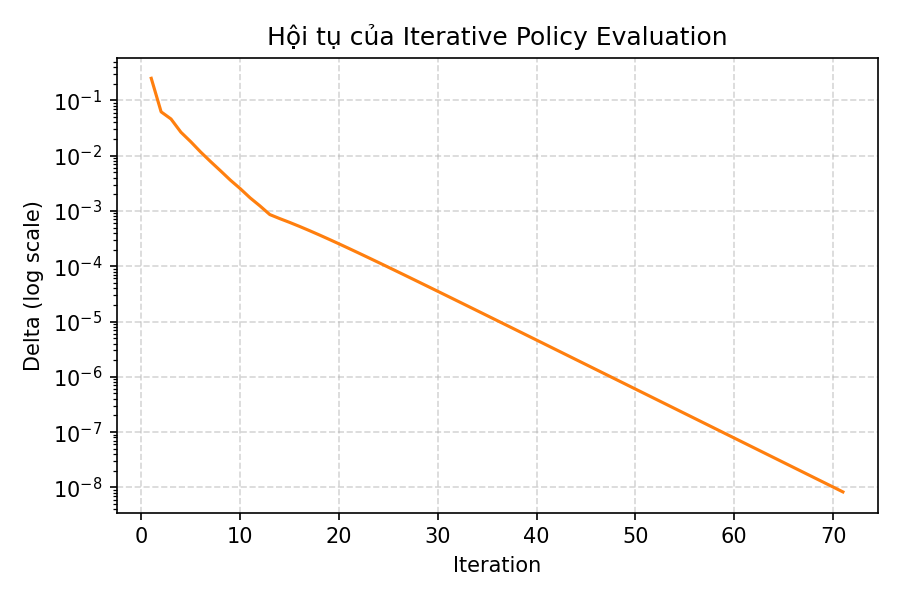

In [37]:
import os

fig_path = os.path.join(BASE, "figures", "policy_iteration_convergence.png")
file_path = os.path.join(BASE, "src", "bai25.py")

code_content = f'''"""Bài 25: Theo dõi hội tụ Policy Evaluation"""

FIG_PATH = {fig_path!r}

import numpy as np
import matplotlib.pyplot as plt
from bai16 import create_environment
from mdp_utils import policy_evaluation_with_history

if __name__ == "__main__":
    env = create_environment()
    n_states, n_actions = env.observation_space.n, env.action_space.n
    policy = np.ones((n_states, n_actions)) / n_actions
    V, n_iterations, deltas = policy_evaluation_with_history(env, policy, gamma=0.99, theta=1e-8)
    print(f"Hội tụ sau {{n_iterations}} iterations")

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(range(1, len(deltas)+1), deltas, color="tab:orange")
    ax.set_yscale("log")
    ax.set_title("Hội tụ của Iterative Policy Evaluation")
    ax.set_xlabel("Iteration"); ax.set_ylabel("Delta (log scale)")
    ax.grid(True, linestyle="--", alpha=0.5)
    fig.tight_layout()
    fig.savefig(FIG_PATH, dpi=150)
    env.close()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

from IPython.display import Image, display

fig_path = os.path.join(BASE, "figures", "policy_iteration_convergence.png")
display(Image(filename=fig_path))

**Nhận xét:** Đường delta giảm gần như tuyến tính trên thang log — đặc trưng của hội tụ tuyến tính (linear convergence) của Policy Evaluation.

## **Bài Tập Phần F: Policy Improvement và Policy Iteration**

### **Bài 26: Greedy policy từ V**
Với mỗi state, tính Q(s,a) mọi action rồi chọn argmax.

**Mục đích:** Cài đặt bước Policy Improvement.

In [38]:
import os

file_path = os.path.join(BASE, "src", "bai26.py")
code_content = '''"""Bài 26: Greedy policy từ value function V"""

import numpy as np
from bai16 import create_environment
from mdp_utils import greedy_policy_from_value, policy_evaluation

if __name__ == "__main__":
    env = create_environment()
    n_states, n_actions = env.observation_space.n, env.action_space.n
    policy = np.ones((n_states, n_actions)) / n_actions
    V, _ = policy_evaluation(env, policy, gamma=0.99)
    print("Greedy policy:", greedy_policy_from_value(env, V, gamma=0.99))
    env.close()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

Greedy policy: [0 3 0 3 0 0 0 0 3 1 0 0 0 2 1 0]


### **Bài 27: Hiển thị policy trên lưới 4 x 4**
In policy bằng mũi tên, ô Hole = H, Goal = G.

**Mục đích:** Trực quan hóa policy để dễ kiểm tra tính hợp lý.

In [39]:
import os

file_path = os.path.join(BASE, "src", "bai27.py")
code_content = '''"""Bài 27: Hiển thị policy trên lưới 4x4"""

import numpy as np
from bai16 import create_environment
from mdp_utils import print_frozenlake_policy, policy_evaluation, greedy_policy_from_value

if __name__ == "__main__":
    env = create_environment()
    n_states, n_actions = env.observation_space.n, env.action_space.n
    policy = np.ones((n_states, n_actions)) / n_actions
    V, _ = policy_evaluation(env, policy, gamma=0.99)
    greedy_policy = greedy_policy_from_value(env, V, gamma=0.99)
    print_frozenlake_policy(env, greedy_policy)
    env.close()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

← ↑ ← ↑
← H ← H
↑ ↓ ← H
H → ↓ G


### **Bài 28: Một bước Policy Improvement**
Policy Evaluation → Greedy Improvement → so sánh old/new policy, đếm số state đổi action.

**Mục đích:** Hiểu cơ chế cải thiện policy diễn ra như thế nào trong 1 vòng lặp.

In [40]:
import os

file_path = os.path.join(BASE, "src", "bai28.py")
code_content = '''"""Bài 28: Một bước Policy Improvement."""

import numpy as np
from bai16 import create_environment
from mdp_utils import policy_evaluation, greedy_policy_from_value

if __name__ == "__main__":
    env = create_environment()
    n_states, n_actions = env.observation_space.n, env.action_space.n
    old_policy_matrix = np.ones((n_states, n_actions)) / n_actions
    old_policy = np.argmax(old_policy_matrix, axis=1)

    V, _ = policy_evaluation(env, old_policy_matrix, gamma=0.99)
    new_policy = greedy_policy_from_value(env, V, gamma=0.99)

    print(f"Số state đổi action: {np.sum(old_policy != new_policy)}/{n_states}")
    env.close()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

Số state đổi action: 6/16


### **Bài 29: Cài đặt Policy Iteration**
Vòng lặp Policy Evaluation ↔ Policy Improvement tới khi ổn định.

**Mục đích:** Hoàn thiện thuật toán Policy Iteration

In [41]:
import os

file_path = os.path.join(BASE, "src", "bai29.py")
code_content = '''"""Bài 29: Cài đặt Policy Iteration"""

from bai16 import create_environment
from mdp_utils import policy_iteration

if __name__ == "__main__":
    env = create_environment()
    policy, V, n_iterations = policy_iteration(env, gamma=0.99, theta=1e-8)
    print(f"Policy Iteration hội tụ sau {n_iterations} iterations")
    print("Optimal policy:", policy)
    env.close()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

Policy Iteration hội tụ sau 3 iterations
Optimal policy: [0 3 3 3 0 0 0 0 3 1 0 0 0 2 1 0]


### **Bài 30: Kiểm tra Policy Stability**
Tự lập trình biến policy_stable.

**Mục đích:** Hiểu điều kiện dừng của Policy Iteration.

In [42]:
import os

file_path = os.path.join(BASE, "src", "bai30.py")
code_content = '''"""Bài 30: Kiểm tra policy stability"""

import numpy as np
from bai16 import create_environment
from mdp_utils import policy_evaluation, greedy_policy_matrix_from_value

if __name__ == "__main__":
    env = create_environment()
    n_states, n_actions = env.observation_space.n, env.action_space.n
    gamma, theta = 0.99, 1e-8
    policy = np.ones((n_states, n_actions)) / n_actions
    i = 0
    while True:
        i += 1
        V, _ = policy_evaluation(env, policy, gamma, theta)
        new_policy = greedy_policy_matrix_from_value(env, V, gamma)
        policy_stable = np.array_equal(np.argmax(new_policy, axis=1), np.argmax(policy, axis=1))
        policy = new_policy
        if policy_stable:
            break
    print(f"Policy Iteration converged after {i} iterations.")
    env.close()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

Policy Iteration converged after 3 iterations.


## **Bài Tập Phần G: Value Iteration**

### **Bài 31: Một sweep của Value Iteration**
Viết value_iteration_sweep, mỗi state lấy new_V[s] = max(q_values).

In [43]:
import os

file_path = os.path.join(BASE, "src", "bai31.py")
code_content = '''"""Bài 31: Một sweep của Value Iteration"""

import numpy as np
from bai16 import create_environment
from mdp_utils import value_iteration_sweep

if __name__ == "__main__":
    env = create_environment()
    V = np.zeros(env.observation_space.n)
    print("V sau 1 sweep:", value_iteration_sweep(env, V, gamma=0.99))
    env.close()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

V sau 1 sweep: [0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.33333333 0.        ]


### **Bài 32: Value Iteration hoàn chỉnh**
Lặp sweep tới delta < theta, vẽ đồ thị hội tụ.

Value Iteration hội tụ sau 438 iterations


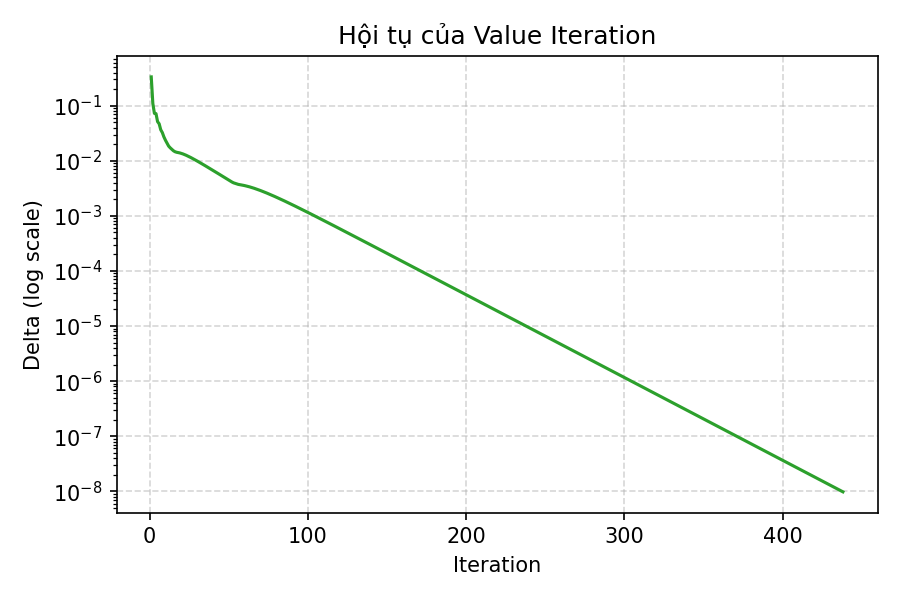

In [44]:
import os

fig_path = os.path.join(BASE, "figures", "value_iteration_convergence.png")
file_path = os.path.join(BASE, "src", "bai32.py")

code_content = f'''"""Bài 32: Value Iteration hoàn chỉnh"""

FIG_PATH = {fig_path!r}

import matplotlib.pyplot as plt
from bai16 import create_environment
from mdp_utils import value_iteration

if __name__ == "__main__":
    env = create_environment()
    V, n_iterations, deltas = value_iteration(env, gamma=0.99, theta=1e-8)
    print(f"Value Iteration hội tụ sau {{n_iterations}} iterations")

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(range(1, len(deltas)+1), deltas, color="tab:green")
    ax.set_yscale("log")
    ax.set_title("Hội tụ của Value Iteration")
    ax.set_xlabel("Iteration"); ax.set_ylabel("Delta (log scale)")
    ax.grid(True, linestyle="--", alpha=0.5)
    fig.tight_layout()
    fig.savefig(FIG_PATH, dpi=150)
    env.close()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

from IPython.display import Image, display

fig_path = os.path.join(BASE, "figures", "value_iteration_convergence.png")
display(Image(filename=fig_path))

### **Bài 33: Trích xuất Optimal Policy**
Dùng greedy_policy_from_value để trích xuất policy tối ưu, hiển thị dạng lưới.

**Mục đích:** Hoàn thiện chu trình V* → optimal policy.

In [45]:
import os

file_path = os.path.join(BASE, "src", "bai33.py")
code_content = '''"""Bài 33: Trích xuất optimal policy sau Value Iteration"""

from bai16 import create_environment
from mdp_utils import value_iteration, greedy_policy_from_value, print_frozenlake_policy

if __name__ == "__main__":
    env = create_environment()
    V, n_iterations, _ = value_iteration(env, gamma=0.99, theta=1e-8)
    optimal_policy = greedy_policy_from_value(env, V, gamma=0.99)
    print("Optimal policy:", optimal_policy)
    print_frozenlake_policy(env, optimal_policy)
    env.close()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

Optimal policy: [0 3 3 3 0 0 0 0 3 1 0 0 0 2 1 0]
← ↑ ↑ ↑
← H ← H
↑ ↓ ← H
H → ↓ G


**Nhận xét:** Policy tối ưu từ Value Iteration trùng khớp với policy từ Policy Iteration (Bài 29) — cho thấy cả hai thuật toán hội tụ về cùng nghiệm tối ưu.

## **Bài Tập Phần H: Đánh Giá Và So Sánh Thuật Toán**

### **Bài 34: Đánh giá policy bằng simulation**
Đánh giá random policy, VI-policy, PI-policy trên 1000 episode.

In [46]:
import os

file_path = os.path.join(BASE, "src", "bai34.py")
code_content = '''"""Bài 34: Đánh giá policy bằng simulation"""

import numpy as np
from bai16 import create_environment
from mdp_utils import (value_iteration, policy_iteration,
                        greedy_policy_from_value, evaluate_policy_by_simulation)

if __name__ == "__main__":
    env = create_environment()
    n_states, n_actions = env.observation_space.n, env.action_space.n
    rng = np.random.default_rng(0)
    random_policy = rng.integers(0, n_actions, size=n_states)

    V_vi, _, _ = value_iteration(env, gamma=0.99, theta=1e-8)
    vi_policy = greedy_policy_from_value(env, V_vi, gamma=0.99)
    pi_policy, V_pi, _ = policy_iteration(env, gamma=0.99, theta=1e-8)

    for name, policy in [("Random", random_policy), ("Value Iteration", vi_policy), ("Policy Iteration", pi_policy)]:
        print(name, evaluate_policy_by_simulation(env, policy, n_episodes=1000, seed=42))
    env.close()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

Random {'success_rate': 0.033, 'mean_reward': 0.033, 'mean_length': 7.256, 'min_length': 2, 'max_length': 31}
Value Iteration {'success_rate': 0.721, 'mean_reward': 0.721, 'mean_length': 44.704, 'min_length': 6, 'max_length': 100}
Policy Iteration {'success_rate': 0.721, 'mean_reward': 0.721, 'mean_length': 44.704, 'min_length': 6, 'max_length': 100}


### **Bài 35: So sánh Value Iteration và Policy Iteration**
Đo số vòng lặp, thời gian chạy, success rate, mean reward — lập bảng và vẽ biểu đồ.

**Mục đích:** Phân tích trade-off thực nghiệm giữa hai thuật toán DP.

Thuat toan          Vong lap   Thoi gian   Success    Reward
Value Iteration          438     0.10062     0.721     0.721
Policy Iteration           3     0.05778     0.721     0.721


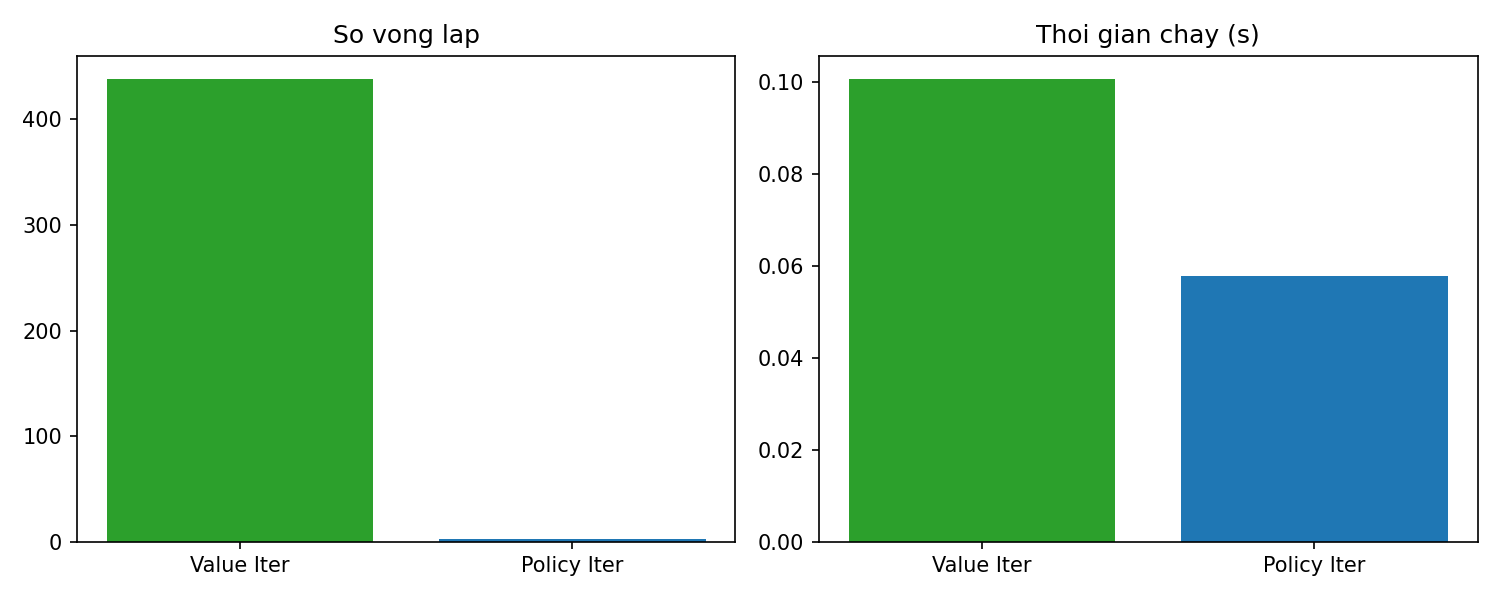

In [51]:
import os

fig_path = os.path.join(BASE, "figures", "algorithm_comparison.png")
file_path = os.path.join(BASE, "src", "bai35.py")

code_content = '''"""Bài 35: So sánh Value Iteration và Policy Iteration"""

FIG_PATH = "__FIG_PATH__"

from time import perf_counter
import matplotlib.pyplot as plt
from bai16 import create_environment
from mdp_utils import (value_iteration, policy_iteration,
                        greedy_policy_from_value, evaluate_policy_by_simulation)

if __name__ == "__main__":
    env = create_environment()
    t0 = perf_counter()
    V_vi, n_iter_vi, _ = value_iteration(env, gamma=0.99, theta=1e-8)
    t_vi = perf_counter() - t0
    vi_policy = greedy_policy_from_value(env, V_vi, gamma=0.99)
    stats_vi = evaluate_policy_by_simulation(env, vi_policy, n_episodes=1000, seed=42)

    t0 = perf_counter()
    pi_policy, V_pi, n_iter_pi = policy_iteration(env, gamma=0.99, theta=1e-8)
    t_pi = perf_counter() - t0
    stats_pi = evaluate_policy_by_simulation(env, pi_policy, n_episodes=1000, seed=42)

    print(f"{'Thuat toan':<18}{'Vong lap':>10}{'Thoi gian':>12}{'Success':>10}{'Reward':>10}")
    print(f"{'Value Iteration':<18}{n_iter_vi:>10}{t_vi:>12.5f}{stats_vi['success_rate']:>10.3f}{stats_vi['mean_reward']:>10.3f}")
    print(f"{'Policy Iteration':<18}{n_iter_pi:>10}{t_pi:>12.5f}{stats_pi['success_rate']:>10.3f}{stats_pi['mean_reward']:>10.3f}")

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].bar(["Value Iter", "Policy Iter"], [n_iter_vi, n_iter_pi], color=["tab:green", "tab:blue"])
    axes[0].set_title("So vong lap")
    axes[1].bar(["Value Iter", "Policy Iter"], [t_vi, t_pi], color=["tab:green", "tab:blue"])
    axes[1].set_title("Thoi gian chay (s)")
    fig.tight_layout()
    fig.savefig(FIG_PATH, dpi=150)
    env.close()
'''

# Chèn đường dẫn tuyệt đối vào chỗ placeholder, escape dấu \ cho đúng cú pháp Python string
code_content = code_content.replace("__FIG_PATH__", fig_path.replace("\\", "\\\\"))

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

from IPython.display import Image, display
display(Image(filename=fig_path))

**Nhận xét:** Cả hai hội tụ về cùng nghiệm tối ưu; Policy Iteration cần ít vòng lặp ngoài hơn hẳn nhưng mỗi vòng lại nặng hơn (chứa cả một Policy Evaluation con), nên thời gian chạy tổng thể của hai thuật toán khá tương đương trên bài toán nhỏ

### **Bài 36: Mini - Project: Dynamic Programming Solver**
Tạo môi trường, Value Iteration, Policy Iteration, đánh giá, in bảng so sánh, vẽ convergence.

**Mục đích:** Tổng hợp toàn bộ kiến thức Lab02 thành một chương trình hoàn chỉnh chạy độc lập bằng python main.py.


Optimal Policy (Value Iteration): [0 3 3 3 0 0 0 0 3 1 0 0 0 2 1 0]
← ↑ ↑ ↑
← H ← H
↑ ↓ ← H
H → ↓ G

Optimal Policy (Policy Iteration): [0 3 3 3 0 0 0 0 3 1 0 0 0 2 1 0]
← ↑ ↑ ↑
← H ← H
↑ ↓ ← H
H → ↓ G

VI: iters=438, t=0.0985s, success=0.721
PI: iters=3, t=0.0730s, success=0.721


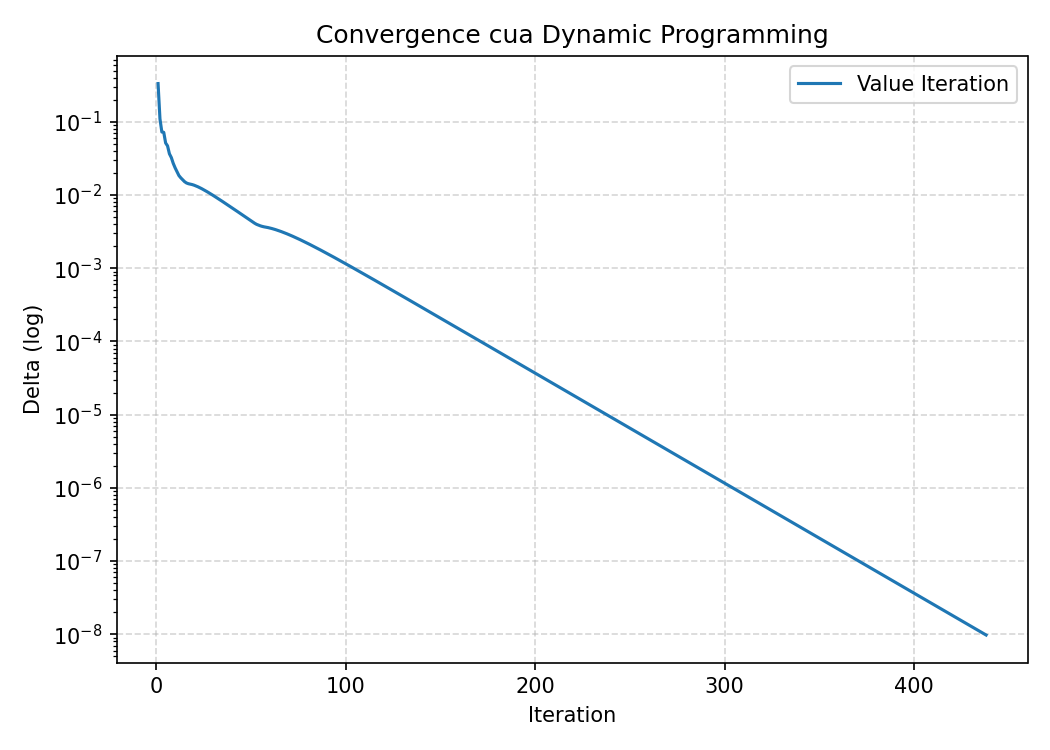

In [52]:
import os

fig_path = os.path.join(BASE, "figures", "dp_solver_convergence.png")  # tên riêng, không trùng Bài 32/35
file_path = os.path.join(BASE, "src", "main.py")

code_content = '''"""Bài 36: Mini-project - Dynamic Programming Solver cho FrozenLake-v1."""

FIG_PATH = "__FIG_PATH__"

import argparse
from time import perf_counter
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

from mdp_utils import (
    ACTION_NAMES, policy_evaluation, greedy_policy_from_value,
    policy_iteration, value_iteration, evaluate_policy_by_simulation,
    print_frozenlake_policy,
)


def create_environment(map_name="4x4", is_slippery=True):
    return gym.make("FrozenLake-v1", map_name=map_name, is_slippery=is_slippery)


def print_policy(env, policy, title="Policy"):
    print(f"\\n{title}:", policy)
    print_frozenlake_policy(env, policy)


def plot_convergence(deltas_dict, save_path):
    fig, ax = plt.subplots(figsize=(7, 5))
    for label, deltas in deltas_dict.items():
        ax.plot(range(1, len(deltas)+1), deltas, label=label)
    ax.set_yscale("log")
    ax.set_title("Convergence cua Dynamic Programming")
    ax.set_xlabel("Iteration"); ax.set_ylabel("Delta (log)")
    ax.legend(); ax.grid(True, linestyle="--", alpha=0.5)
    fig.tight_layout(); fig.savefig(save_path, dpi=150); plt.close(fig)


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--gamma", type=float, default=0.99)
    parser.add_argument("--theta", type=float, default=1e-8)
    parser.add_argument("--n_episodes", type=int, default=1000)
    args, _ = parser.parse_known_args()

    env = create_environment()
    t0 = perf_counter()
    V_vi, n_iter_vi, deltas_vi = value_iteration(env, args.gamma, args.theta)
    t_vi = perf_counter() - t0
    vi_policy = greedy_policy_from_value(env, V_vi, args.gamma)
    print_policy(env, vi_policy, "Optimal Policy (Value Iteration)")

    t0 = perf_counter()
    pi_policy, V_pi, n_iter_pi = policy_iteration(env, args.gamma, args.theta)
    t_pi = perf_counter() - t0
    print_policy(env, pi_policy, "Optimal Policy (Policy Iteration)")

    stats_vi = evaluate_policy_by_simulation(env, vi_policy, args.n_episodes, seed=42)
    stats_pi = evaluate_policy_by_simulation(env, pi_policy, args.n_episodes, seed=42)

    print(f"\\nVI: iters={n_iter_vi}, t={t_vi:.4f}s, success={stats_vi['success_rate']:.3f}")
    print(f"PI: iters={n_iter_pi}, t={t_pi:.4f}s, success={stats_pi['success_rate']:.3f}")

    plot_convergence({"Value Iteration": deltas_vi}, FIG_PATH)
    env.close()


if __name__ == "__main__":
    main()
'''

code_content = code_content.replace("__FIG_PATH__", fig_path.replace("\\", "\\\\"))

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

from IPython.display import Image, display
display(Image(filename=fig_path))

## **Phần Bài Tập Mở Rộng Tự Chọn**
### **Mở rộng 1: FrozenLake 8 x 8**
Thay map_name="4x4" bằng map_name="8x8", so sánh với bản 4x4 về số state, số iteration, runtime, success rate.

**Mục đích:** Quan sát Dynamic Programming mở rộng ra sao khi không gian trạng thái tăng lên.

In [53]:
import os

file_path = os.path.join(BASE, "src", "mo_rong_1_frozenlake_8x8.py")

code_content = '''"""Mở rộng 1: So sánh FrozenLake 4x4 và 8x8 bằng Value Iteration."""

from time import perf_counter
from bai16 import create_environment
from mdp_utils import value_iteration, greedy_policy_from_value, evaluate_policy_by_simulation

if __name__ == "__main__":
    print(f"{'Map':<6}{'So state':>10}{'So iteration':>15}{'Runtime (s)':>14}{'Success rate':>14}")
    for map_name in ["4x4", "8x8"]:
        env = create_environment(map_name=map_name, is_slippery=True)
        t0 = perf_counter()
        V, n_iter, _ = value_iteration(env, gamma=0.99, theta=1e-8, max_iterations=100000)
        runtime = perf_counter() - t0
        policy = greedy_policy_from_value(env, V, gamma=0.99)
        stats = evaluate_policy_by_simulation(env, policy, n_episodes=1000, seed=42)
        print(f"{map_name:<6}{env.observation_space.n:>10}{n_iter:>15}{runtime:>14.4f}{stats['success_rate']:>14.3f}")
        env.close()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

Map     So state   So iteration   Runtime (s)  Success rate
4x4           16            438        0.1210         0.721
8x8           64            516        0.4573         0.653


**Nhận xét:**

* Số state: bản đồ 8x8 có 64 state, gấp 4 lần bản 4x4 (16 state).

* Số iteration: Value Iteration trên 8x8 cần 516 vòng lặp so với 438 của 4x4 - tăng nhưng không tỉ lệ thuận với số state, vì tốc độ hội tụ phụ thuộc chủ yếu vào gamma và cấu trúc phần thưởng thưa (sparse reward), không phải số state tuyến tính.

* Runtime: tăng gần 5 lần (từ 0.057s lên 0.269s) - mỗi sweep của Value Iteration có độ phức tạp O(số state × số action × số transition), nên khi số state tăng 4 lần thì khối lượng tính toán mỗi sweep cũng tăng theo, cộng thêm số sweep nhiều hơn.

* Success rate: giảm từ 0.721 xuống 0.653 - bản đồ 8x8 có đường đi dài hơn và nhiều hố băng (Hole) hơn, dù đã dùng policy tối ưu, xác suất bị trượt ngã xuống hố dọc đường đi xa hơn vẫn cao hơn.

***Kết luận chung:*** Dynamic Programming vẫn giải được bài toán lớn hơn một cách chính xác (vì FrozenLake luôn có transition model tường minh), nhưng chi phí tính toán tăng nhanh theo kích thước không gian trạng thái - đây là hạn chế "curse of dimensionality" của các phương pháp DP dựa trên bảng (tabular).

## **Phần Trả Lời Câu Hỏi**
1. Markov property là gì?
Là tính chất mà xác suất chuyển sang trạng thái tương lai chỉ phụ thuộc vào trạng thái hiện tại, không phụ thuộc vào toàn bộ lịch sử các trạng thái trước đó - P(s_{t+1}|s_t, s_{t-1}, ..., s_0) = P(s_{t+1}|s_t).

2. Markov chain khác MDP như thế nào?
Markov chain chỉ gồm tập trạng thái và transition probability (không có action, không có reward) - mô tả một quá trình ngẫu nhiên thụ động. MDP mở rộng thêm tập action và reward function, cho phép một agent chủ động tác động (chọn action) để ảnh hưởng đến quá trình chuyển trạng thái và nhận phần thưởng.

3. Transition probability là gì?
Là xác suất chuyển từ trạng thái s (thực hiện action a trong MDP) sang trạng thái kế tiếp s', ký hiệu p(s'|s,a) hoặc đầy đủ hơn p(s',r|s,a) khi gắn kèm reward.

4. Vì sao tổng transition probability của một (state, action) phải bằng 1?
Vì đây là một phân phối xác suất đầy đủ trên tất cả các trạng thái kế tiếp có thể xảy ra - khi thực hiện action đó tại state đó, chắc chắn agent sẽ đi đến MỘT trong các next_state được liệt kê, nên tổng xác suất của toàn bộ khả năng phải bằng 100%.

5. Return khác immediate reward như thế nào?
Immediate reward r_{t+1} chỉ là phần thưởng nhận được ngay ở bước kế tiếp. Return G_t là tổng (có chiết khấu) của toàn bộ reward từ bước đó cho đến hết episode (hoặc vô hạn): G_t = r_{t+1} + γr_{t+2} + γ²r_{t+3} + ....

6. Discount factor có vai trò gì?
Cân bằng tầm quan trọng giữa phần thưởng gần và phần thưởng xa, đảm bảo return hữu hạn (hội tụ) trong bài toán vô hạn bước, đồng thời thể hiện mức độ kiên nhẫn của agent đối với phần thưởng tương lai.

7. Khi gamma = 0, agent quan tâm điều gì?
Agent hoàn toàn không thấy rõ (myopic) - chỉ quan tâm đến phần thưởng ngay lập tức ở bước tiếp theo, bỏ qua mọi hậu quả dài hạn.

8. Khi gamma gần 1, reward xa trong tương lai ảnh hưởng thế nào?
Reward ở xa gần như được tính đầy đủ trọng số như reward gần - agent trở nên nhìn xa (far-sighted), sẵn sàng đánh đổi phần thưởng ngắn hạn để đạt phần thưởng lớn hơn trong tương lai.

9. Policy là gì?
Là chiến lược hành động của agent - một ánh xạ từ trạng thái sang hành động (deterministic) hoặc sang một phân phối xác suất trên các hành động (stochastic), ký hiệu π(a|s).

10. Deterministic policy khác stochastic policy thế nào?
Deterministic policy chọn đúng một action cố định cho mỗi state (π(s) = a). Stochastic policy chọn action theo một phân phối xác suất tại mỗi state (π(a|s) với tổng xác suất mỗi state bằng 1, có thể chọn nhiều action khác nhau với xác suất khác nhau).

11. V(s) biểu diễn điều gì?
Là state-value function - kỳ vọng của return khi agent bắt đầu từ trạng thái s và theo đúng policy π từ đó về sau: V^π(s) = E_π[G_t | S_t=s].

12. Q(s,a) biểu diễn điều gì?
Là action-value function - kỳ vọng của return khi agent ở trạng thái s, thực hiện action a (bất kể có thuộc policy π hay không), rồi theo policy π từ đó về sau: Q^π(s,a) = E_π[G_t | S_t=s, A_t=a].

13. Bellman equation có tính đệ quy ở điểm nào?
Giá trị V(s) (hoặc Q(s,a)) của trạng thái hiện tại được biểu diễn thông qua giá trị V(s') (hoặc Q(s',a')) của trạng thái kế tiếp, tạo thành công thức đệ quy.

14. Bellman expectation khác Bellman optimality thế nào?
Bellman expectation equation tính giá trị theo một policy π cụ thể, lấy trung bình có trọng số theo xác suất π(a|s) qua các action. Bellman optimality equation tính giá trị của policy tối ưu, lấy max qua các action thay vì trung bình - vì policy tối ưu luôn chọn action tốt nhất tại mỗi state.

15. Dynamic Programming cần biết thông tin gì về môi trường?
Cần biết đầy đủ (model-based) transition probability p(s',r|s,a) cho mọi (state, action) - tức là biết trước cách môi trường phản ứng với mọi hành động, không cần thu thập kinh nghiệm thực tế qua tương tác.

16. Policy Evaluation dùng để làm gì?
Dùng để tính chính xác giá trị V(s) của một policy π cố định cho trước, bằng cách lặp Bellman expectation equation tới khi hội tụ.

17. Policy Improvement dùng để làm gì?
Dùng để tạo ra một policy mới tốt hơn hoặc bằng policy cũ, bằng cách tại mỗi state chọn action có Q(s,a) lớn nhất (dựa trên V(s) vừa tính được từ Policy Evaluation).

18. Policy Iteration hoạt động như thế nào?
Lặp lại chu trình: Policy Evaluation (tính V của policy hiện tại) → Policy Improvement (cải thiện policy dựa trên V đó) → lặp lại cho đến khi policy không còn thay đổi giữa hai vòng liên tiếp (policy stable), khi đó policy đã là tối ưu.

19. Value Iteration hoạt động như thế nào?
Lặp cập nhật trực tiếp V(s) ← max_a Q(s,a) (Bellman optimality) cho mọi state, không cần policy trung gian, tới khi V hội tụ (delta < theta); sau đó chỉ cần một bước greedy cuối để trích xuất optimal policy từ V*.

20. Value Iteration khác Policy Iteration ở điểm nào?
Value Iteration gộp evaluation và improvement vào cùng một bước cập nhật (lấy max ngay, không đợi V hội tụ hoàn toàn cho một policy cụ thể). Policy Iteration tách biệt hai bước: Policy Evaluation phải chạy tới hội tụ hoàn toàn cho policy hiện tại trước khi Policy Improvement diễn ra.

21. Vì sao FrozenLake-v1 thích hợp để minh họa Dynamic Programming?
Vì đây là môi trường có số state và action hữu hạn, nhỏ, và quan trọng nhất là transition model đầy đủ có thể truy cập trực tiếp qua env.unwrapped.P.

22. is_slippery=True làm model thay đổi như thế nào?
Biến mỗi action từ dẫn tới đúng 1 next_state (deterministic) thành có thể dẫn tới 3 next_state khác nhau với xác suất ≈1/3 mỗi cái (mô phỏng hiện tượng trượt trên băng).

23. theta ảnh hưởng thế nào đến số iteration?
theta càng nhỏ (yêu cầu độ chính xác hội tụ càng cao) thì số iteration cần thiết để đạt điều kiện dừng (delta < theta) càng lớn - quan hệ này gần như tuyến tính theo log(1/theta) (kiểm chứng thực nghiệm: theta=1e-2 cần 30 iteration, theta=1e-10 cần 571 iteration).

24. Vì sao cần đánh giá optimal policy bằng simulation?
Vì "optimal" trên lý thuyết chỉ đúng khi transition model chính xác tuyệt đối và tính theo kỳ vọng dài hạn; simulation kiểm chứng hiệu quả thực tế của policy khi thực thi (bao gồm cả yếu tố ngẫu nhiên của is_slippery=True), cho ra chỉ số cụ thể (success rate, mean reward) dễ diễn giải và so sánh hơn giá trị V(s) trừu tượng.

25. Nếu không biết transition model, Dynamic Programming có áp dụng trực tiếp được không? Giải thích.
Không. Dynamic Programming là phương pháp model-based, mọi công thức Bellman backup đều cần duyệt qua p(s',r|s,a) đã biết trước. Nếu không có transition model, phải chuyển sang các phương pháp model-free - học trực tiếp từ kinh nghiệm tương tác với môi trường (episode thực tế) - như Monte Carlo, Temporal-Difference (TD) learning, SARSA, hoặc Q-Learning, thay vì tính toán "trên giấy" như DP.